#**Flood Severity prediction using Random Forest**

In [ ]:
#Loading and Preprocessing data

import pandas as pd

# Load datasets
catchment_df = pd.read_csv("catchment_characteristics_indofloods.csv")
floodevents_df = pd.read_csv("floodevents_indofloods.csv")
metadata_df = pd.read_csv("metadata_indofloods.csv")
precipitation_df = pd.read_csv("precipitation_variables_indofloods.csv")

# Process Flood Events Data
floodevents_df["Start Date"] = pd.to_datetime(floodevents_df["Start Date"])
floodevents_df["End Date"] = pd.to_datetime(floodevents_df["End Date"])

# Label flood severity based on Peak Discharge
floodevents_df["Flood_Severity"] = pd.cut(floodevents_df["Peak Discharge Q (cumec)"],
                                           bins=[0, 500, 2000, 5000, float("inf")],
                                           labels=["None", "Above Normal", "Severe", "Extreme"])

# Process Precipitation Data
rainfall_columns = [col for col in precipitation_df.columns if "T" in col]
precipitation_df["Total_Rainfall_10d"] = precipitation_df[rainfall_columns].sum(axis=1)

# Process Metadata Data
metadata_df = metadata_df[["GaugeID", "Latitude", "Longitude", "Warning Level", "Danger Level", "Basin", "State"]]

# Process Catchment Data - Selecting relevant hydrological and climatic features
catchment_features = ["GaugeID", "Drainage Area", "Catchment Relief", "Drainage Density", "Ruggedness Number",
                      "Annual Precipitation", "Mean Temperature of Wettest Quarter", "Soil type", "Land cover"]
catchment_df = catchment_df[catchment_features]

# Save processed datasets separately
floodevents_df.to_csv("processed_flood_events.csv", index=False)
precipitation_df.to_csv("processed_precipitation.csv", index=False)
metadata_df.to_csv("processed_metadata.csv", index=False)
catchment_df.to_csv("processed_catchment.csv", index=False)

print("Data processing complete. Saved separate processed files.")


Data processing complete. Saved separate processed files.


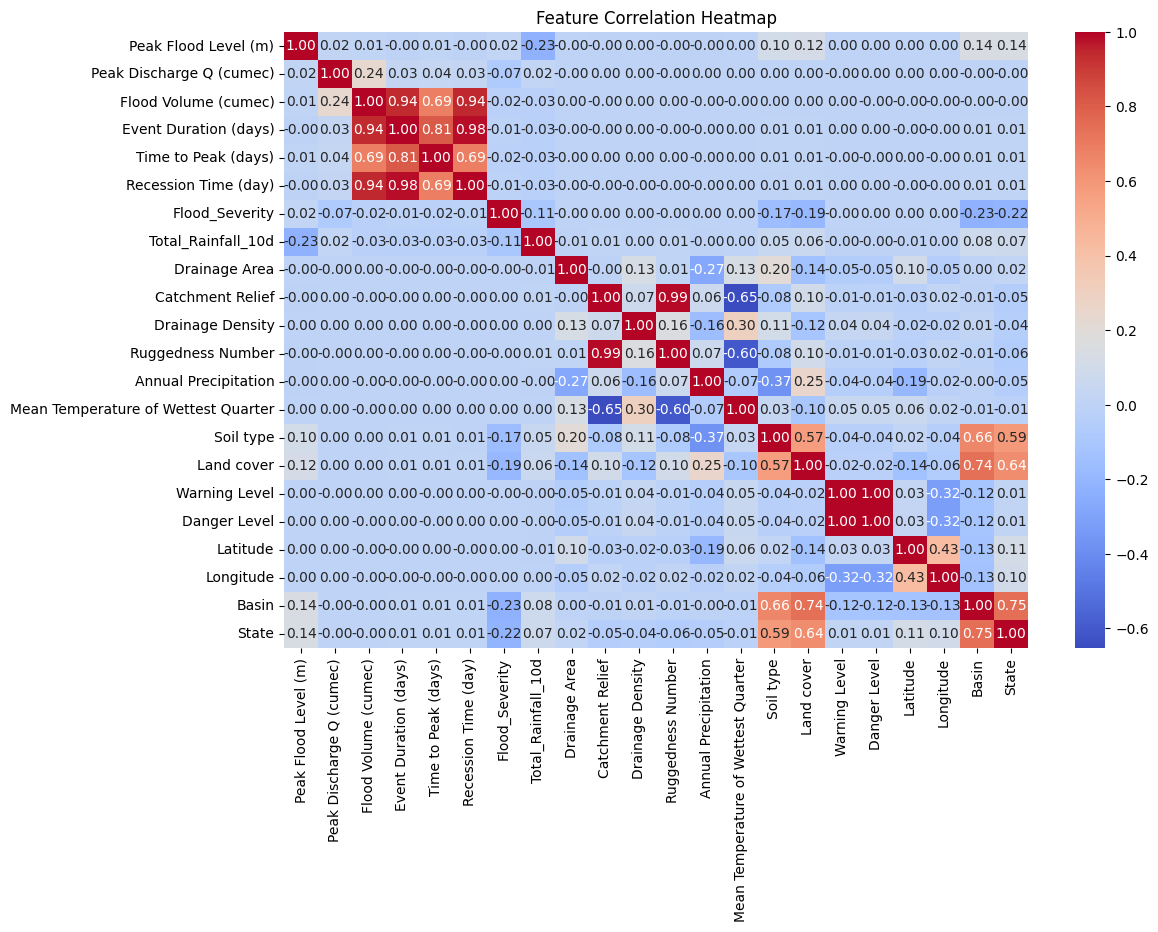

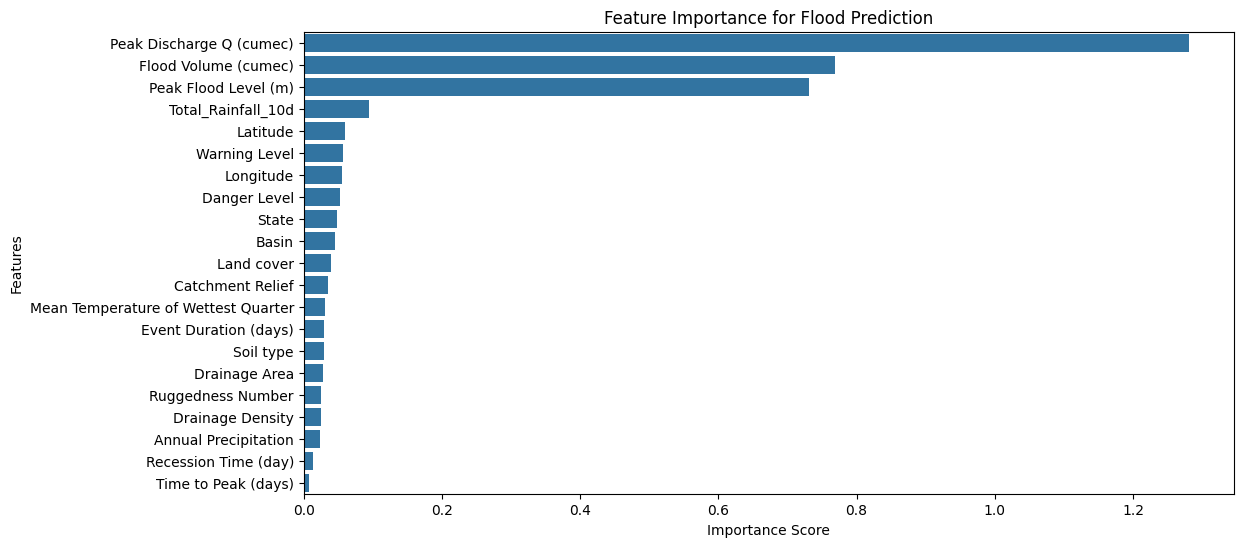

Feature selection complete. Saved as selected_features.csv


In [ ]:
#Feature Selection

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif

# Load processed datasets
flood_events = pd.read_csv("processed_flood_events.csv")
precipitation = pd.read_csv("processed_precipitation.csv")
catchment = pd.read_csv("processed_catchment.csv")
metadata = pd.read_csv("processed_metadata.csv")

# Select relevant features
flood_features = flood_events[["Peak Flood Level (m)", "Peak Discharge Q (cumec)", "Flood Volume (cumec)", "Event Duration (days)", "Time to Peak (days)", "Recession Time (day)", "Flood_Severity"]]
precip_features = precipitation[["Total_Rainfall_10d"]]
catchment_features = catchment[["Drainage Area", "Catchment Relief", "Drainage Density", "Ruggedness Number", "Annual Precipitation", "Mean Temperature of Wettest Quarter", "Soil type", "Land cover"]]
metadata_features = metadata[["Warning Level", "Danger Level", "Latitude", "Longitude", "Basin", "State"]]

# Merge datasets
final_df = pd.concat([flood_features, precip_features, catchment_features, metadata_features], axis=1)

# Handle categorical features
encoder = LabelEncoder()
categorical_cols = ["Soil type", "Land cover", "Basin", "State", "Flood_Severity"]
for col in categorical_cols:
    final_df[col] = encoder.fit_transform(final_df[col].astype(str))

# Handle missing values
numeric_cols = final_df.select_dtypes(include=["number"]).columns
target_cols = final_df.columns.difference(numeric_cols)

imputer_numeric = SimpleImputer(strategy='mean')
imputer_categorical = SimpleImputer(strategy='most_frequent')

final_df[numeric_cols] = imputer_numeric.fit_transform(final_df[numeric_cols])
if not target_cols.empty:
    final_df[target_cols] = imputer_categorical.fit_transform(final_df[target_cols])
#final_df[target_cols] = imputer_categorical.fit_transform(final_df[target_cols])

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(final_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Feature importance using Mutual Information
X = final_df.drop(columns=["Flood_Severity"])
y = final_df["Flood_Severity"]
feature_importances = mutual_info_classif(X, y)
feature_scores = pd.Series(feature_importances, index=X.columns).sort_values(ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_scores, y=feature_scores.index)
plt.title("Feature Importance for Flood Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# Save selected features
selected_features = feature_scores[feature_scores > 0.01].index.tolist()
final_df[selected_features + ["Flood_Severity"]].to_csv("selected_features.csv", index=False)

print("Feature selection complete. Saved as selected_features.csv")


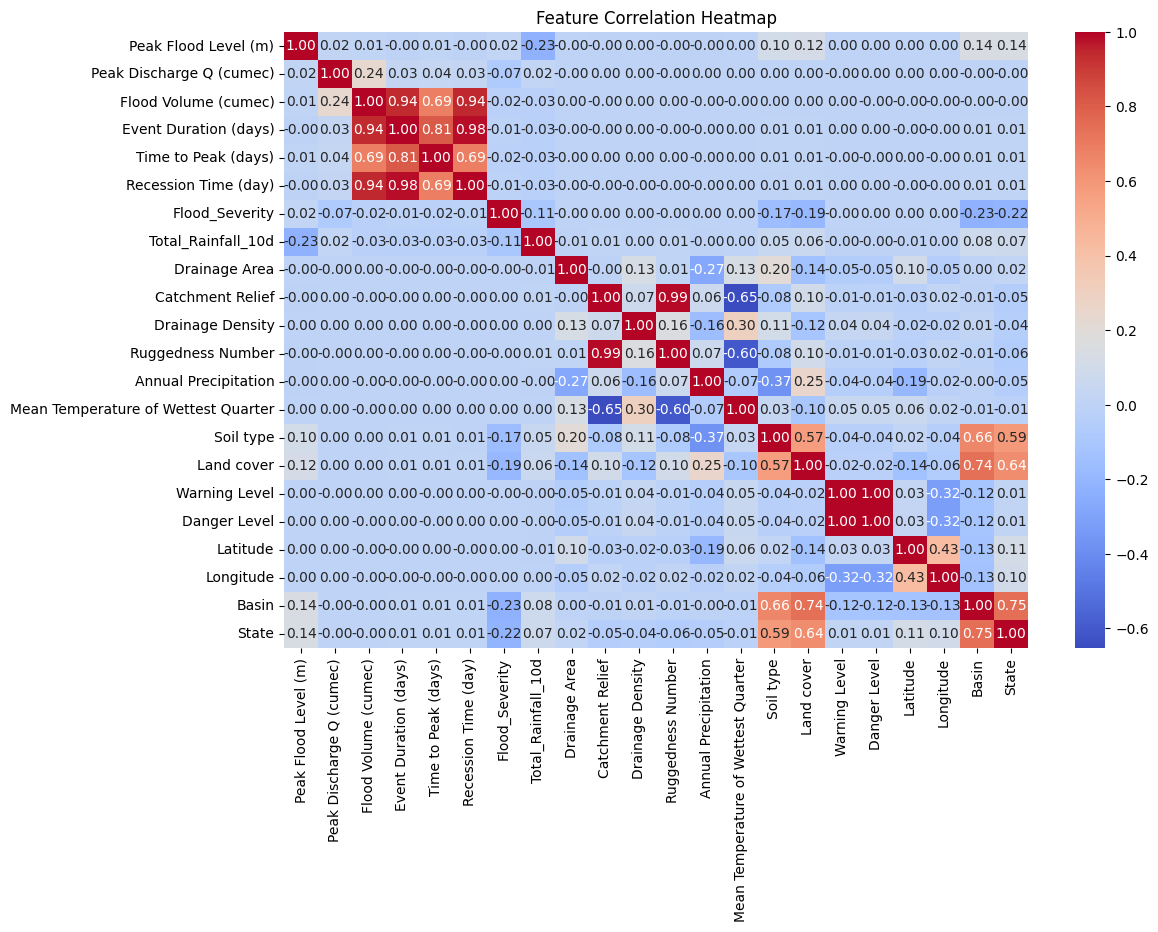

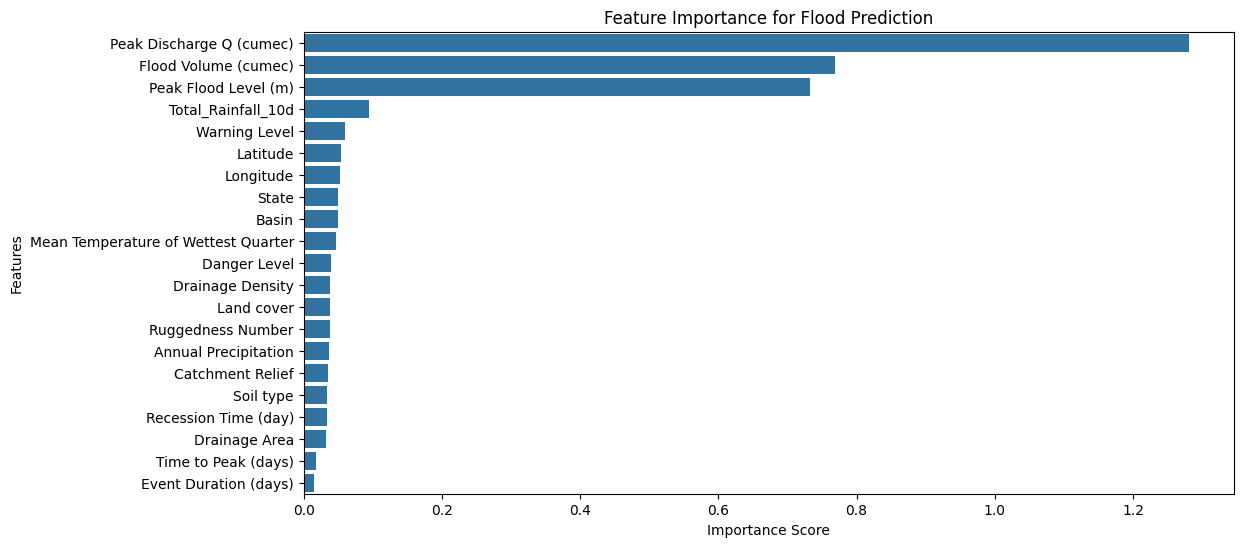

Feature selection complete. Saved as selected_features.csv
Model Accuracy: 0.9978021978021978
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       312
         1.0       1.00      1.00      1.00        81
         2.0       1.00      0.99      0.99       193
         3.0       0.99      1.00      1.00       324

    accuracy                           1.00       910
   macro avg       1.00      1.00      1.00       910
weighted avg       1.00      1.00      1.00       910

Confusion Matrix:
 [[312   0   0   0]
 [  0  81   0   0]
 [  0   0 191   2]
 [  0   0   0 324]]


In [ ]:
#Train and evaluate model

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load processed datasets
flood_events = pd.read_csv("processed_flood_events.csv")
precipitation = pd.read_csv("processed_precipitation.csv")
catchment = pd.read_csv("processed_catchment.csv")
metadata = pd.read_csv("processed_metadata.csv")

# Select relevant features
flood_features = flood_events[["Peak Flood Level (m)", "Peak Discharge Q (cumec)", "Flood Volume (cumec)", "Event Duration (days)", "Time to Peak (days)", "Recession Time (day)", "Flood_Severity"]]
precip_features = precipitation[["Total_Rainfall_10d"]]
catchment_features = catchment[["Drainage Area", "Catchment Relief", "Drainage Density", "Ruggedness Number", "Annual Precipitation", "Mean Temperature of Wettest Quarter", "Soil type", "Land cover"]]
metadata_features = metadata[["Warning Level", "Danger Level", "Latitude", "Longitude", "Basin", "State"]]

# Merge datasets
final_df = pd.concat([flood_features, precip_features, catchment_features, metadata_features], axis=1)

# Handle categorical features
encoder = LabelEncoder()
categorical_cols = ["Soil type", "Land cover", "Basin", "State", "Flood_Severity"]
for col in categorical_cols:
    final_df[col] = encoder.fit_transform(final_df[col].astype(str))

# Handle missing values
numeric_cols = final_df.select_dtypes(include=["number"]).columns
target_cols = final_df.columns.difference(numeric_cols)

imputer_numeric = SimpleImputer(strategy='mean')
imputer_categorical = SimpleImputer(strategy='most_frequent')

final_df[numeric_cols] = imputer_numeric.fit_transform(final_df[numeric_cols])
if not target_cols.empty:
    final_df[target_cols] = imputer_categorical.fit_transform(final_df[target_cols])
#final_df[target_cols] = imputer_categorical.fit_transform(final_df[target_cols])

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(final_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Feature importance using Mutual Information
X = final_df.drop(columns=["Flood_Severity"])
y = final_df["Flood_Severity"]
feature_importances = mutual_info_classif(X, y)
feature_scores = pd.Series(feature_importances, index=X.columns).sort_values(ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_scores, y=feature_scores.index)
plt.title("Feature Importance for Flood Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# Save selected features
selected_features = feature_scores[feature_scores > 0.01].index.tolist()
selected_df = final_df[selected_features + ["Flood_Severity"]]
selected_df.to_csv("selected_features.csv", index=False)

print("Feature selection complete. Saved as selected_features.csv")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(selected_df.drop(columns=["Flood_Severity"]), selected_df["Flood_Severity"], test_size=0.2, random_state=42)

# Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Mean Squared Error (MSE): 0.0022
Root Mean Squared Error (RMSE): 0.0469
Nash-Sutcliffe Efficiency (NSE): 0.9987


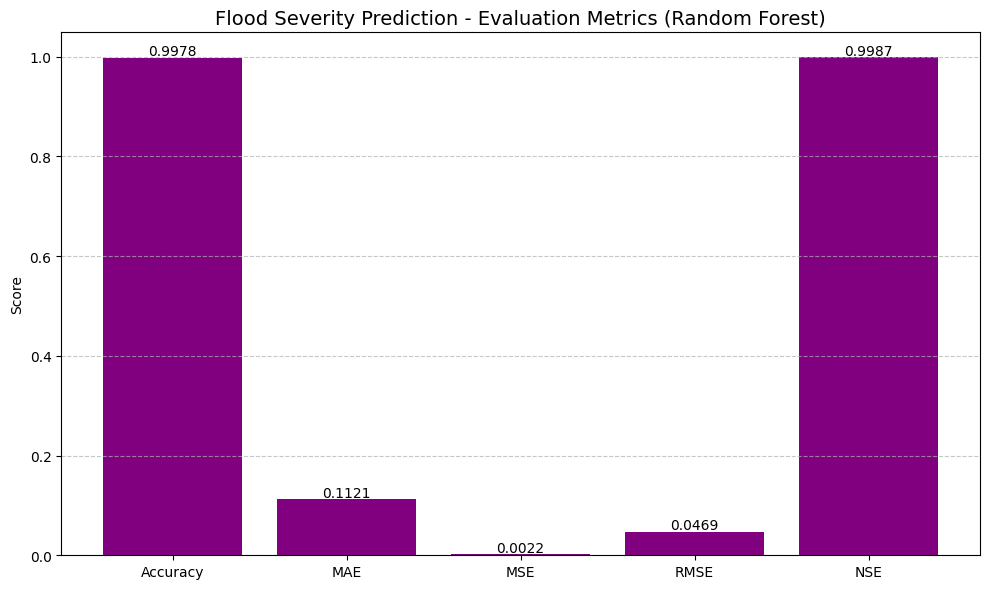

In [ ]:
#Evaluation Metrics

from sklearn.metrics import mean_squared_error

# Compute Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5  # Root Mean Squared Error (RMSE)

# Compute Nash-Sutcliffe Efficiency (NSE)
nse = 1 - (sum((y_test - y_pred) ** 2) / sum((y_test - y_test.mean()) ** 2))

accuracy = accuracy_score(y_test, y_pred)

# Print evaluation metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Nash-Sutcliffe Efficiency (NSE): {nse:.4f}")

from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# If not already class labels, convert predictions
y_pred = model.predict(X_test)
y_test_labels = y_test  # or y_test.argmax(axis=1) if one-hot encoded



# Visualization
metrics = ['Accuracy', 'MAE', 'MSE', 'RMSE', 'NSE']
values = [accuracy, mae, mse, rmse, nse]

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color='purple')
plt.title("Flood Severity Prediction - Evaluation Metrics (Random Forest)", fontsize=14)
plt.ylabel("Score")

# Annotate metric values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.4f}", ha='center', fontsize=10)

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



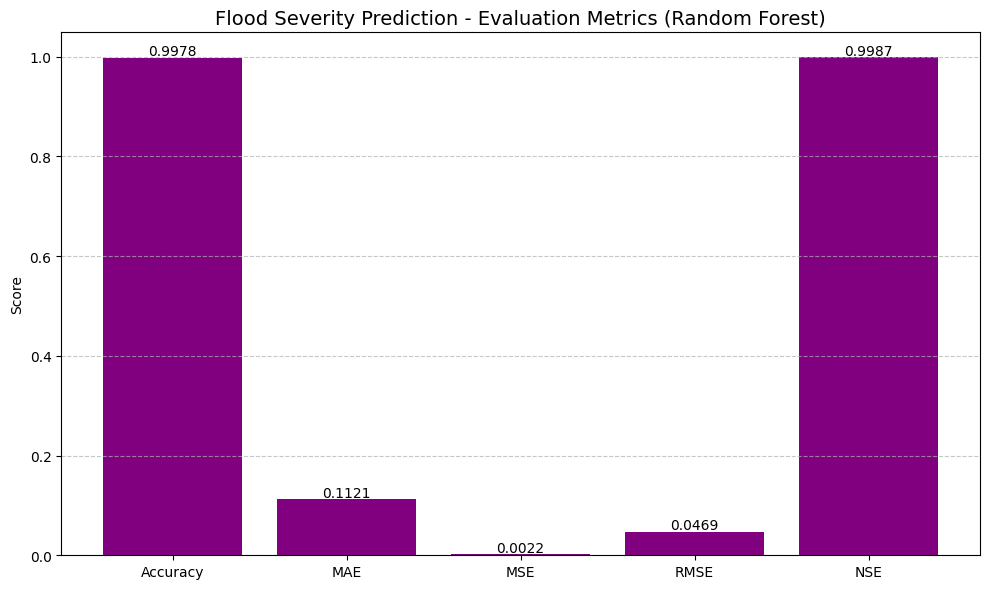

In [ ]:
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# If not already class labels, convert predictions
y_pred = model.predict(X_test)
y_test_labels = y_test  # or y_test.argmax(axis=1) if one-hot encoded



# Visualization
metrics = ['Accuracy', 'MAE', 'MSE', 'RMSE', 'NSE']
values = [accuracy, mae, mse, rmse, nse]

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color='purple')
plt.title("Flood Severity Prediction - Evaluation Metrics (Random Forest)", fontsize=14)
plt.ylabel("Score")

# Annotate metric values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.4f}", ha='center', fontsize=10)

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
# Ensure y_pred is an integer array
y_pred_int = y_pred.astype(int)

# Convert numeric predictions back to original severity labels
predicted_labels = label_encoder.inverse_transform(y_pred_int)

# Convert actual y_test labels back to original severity labels (for comparison)
y_test_int = y_test.astype(int)
actual_labels = label_encoder.inverse_transform(y_test_int)

# Print comparison of actual vs predicted severity
df_results = pd.DataFrame({"Actual Severity": actual_labels, "Predicted Severity": predicted_labels})
print(df_results.head(10))  # Show first 10 results

# Save results for analysis
df_results.to_csv("flood_severity_predictions.csv", index=False)


      Actual Severity  Predicted Severity
0       Extreme Flood       Extreme Flood
1        Severe Flood        Severe Flood
2        Severe Flood        Severe Flood
3        Above Normal        Above Normal
4        Severe Flood        Severe Flood
5        Severe Flood        Severe Flood
6  Catastrophic Flood  Catastrophic Flood
7        Above Normal        Above Normal
8        Severe Flood        Severe Flood
9       Extreme Flood       Extreme Flood


In [ ]:
#Cross validation using k cross fold

from sklearn.model_selection import StratifiedKFold, cross_val_score

# Initialize Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')

# Print results
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())


Cross-Validation Accuracy Scores: [0.99862637 0.99862637 1.         1.         0.99587345]
Mean Accuracy: 0.9986252399594904
Standard Deviation: 0.0015068023682315097


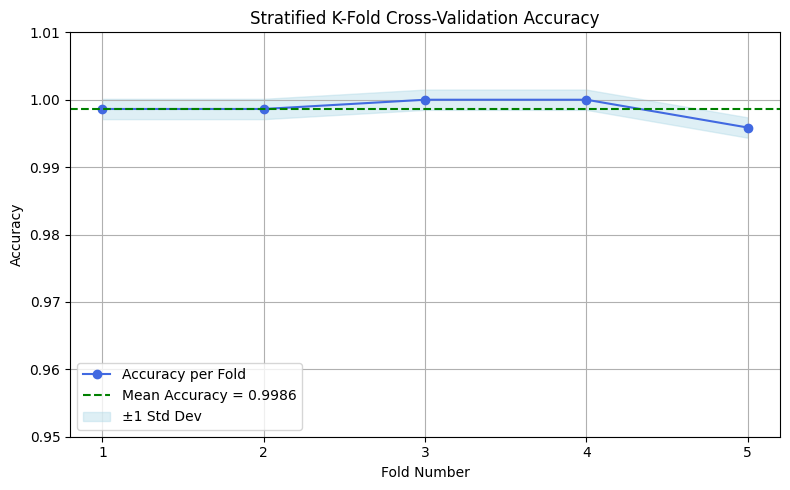

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Cross-validation accuracy scores from your model
cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cv_scores)+1), cv_scores, marker='o', linestyle='-', color='royalblue', label='Accuracy per Fold')
plt.axhline(y=cv_scores.mean(), color='green', linestyle='--', label=f'Mean Accuracy = {cv_scores.mean():.4f}')
plt.fill_between(range(1, len(cv_scores)+1),
                 cv_scores - cv_scores.std(),
                 cv_scores + cv_scores.std(),
                 color='lightblue', alpha=0.4, label='±1 Std Dev')

plt.title('Stratified K-Fold Cross-Validation Accuracy')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.xticks(range(1, len(cv_scores)+1))
plt.ylim(0.95, 1.01)  # Adjust based on your scores
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#**Flood Occurence Prediction using Random Forest**

Model Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       323
           1       1.00      1.00      1.00       587

    accuracy                           1.00       910
   macro avg       1.00      1.00      1.00       910
weighted avg       1.00      1.00      1.00       910


Confusion Matrix:
 [[323   0]
 [  0 587]]

Cross-Validation Accuracy Scores: [0.98131868 0.9989011  1.         1.         0.99339934]
Mean Accuracy: 0.9947238240307547
Standard Deviation: 0.0071355140012885005


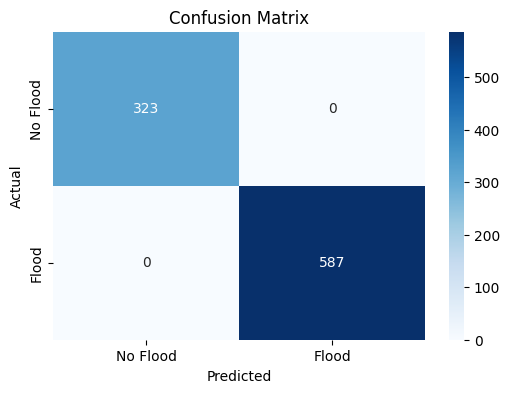

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load processed dataset
final_df = pd.read_csv("selected_features.csv")

# Convert Flood Severity to a binary classification target (Flood Occurrence)
final_df["Flood_Occurrence"] = (final_df["Flood_Severity"] > 0).astype(int)

# Define features (X) and target (y)
X = final_df.drop(columns=["Flood_Severity", "Flood_Occurrence"])  # Features
y = final_df["Flood_Occurrence"]  # Target (0: No Flood, 1: Flood Occurred)

# Split dataset into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train RandomForest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Model evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Cross-validation (5-fold)
cv_scores = cross_val_score(model, X, y, cv=5)
print("\nCross-Validation Accuracy Scores:", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=["No Flood", "Flood"], yticklabels=["No Flood", "Flood"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error

# Additional metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
nse = 1 - (np.sum((y_test - y_pred) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

# Print metrics
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Nash–Sutcliffe Efficiency (NSE): {nse:.4f}")


Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
Mean Absolute Error (MAE): 0.0000
Mean Squared Error (MSE): 0.0000
Root Mean Squared Error (RMSE): 0.0000
Nash–Sutcliffe Efficiency (NSE): 1.0000


<ipython-input-42-faa31a5ce67d>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette='viridis')


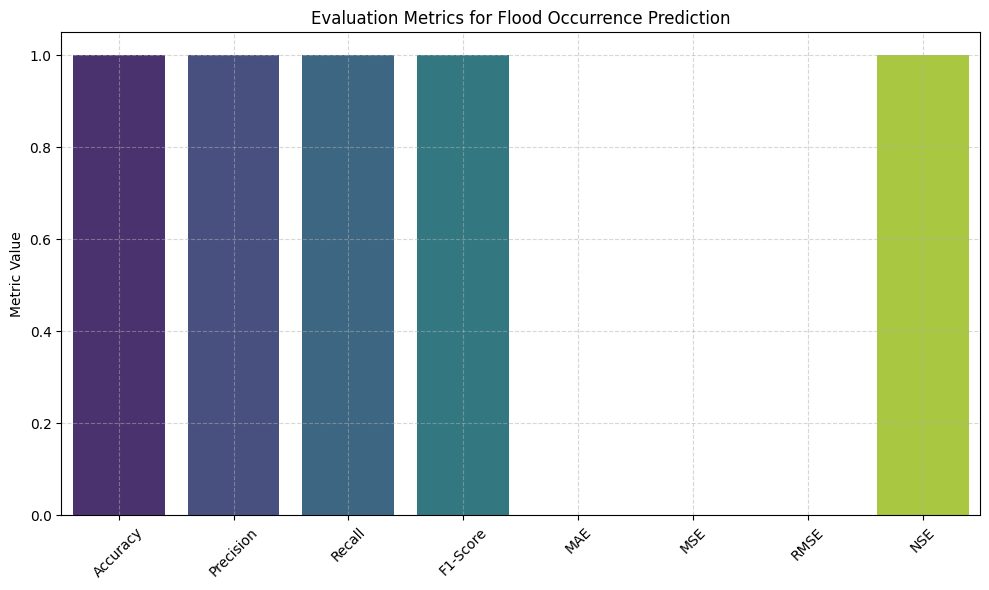

In [ ]:
# Visualization of evaluation metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'MAE', 'MSE', 'RMSE', 'NSE']
values = [accuracy, precision, recall, f1, mae, mse, rmse, nse]

plt.figure(figsize=(10, 6))
sns.barplot(x=metrics, y=values, palette='viridis')
plt.xticks(rotation=45)
plt.title('Evaluation Metrics for Flood Occurrence Prediction')
plt.ylabel('Metric Value')
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
#Recuded max depth to check for overfitting. Its not overfitted

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Decision Tree with max_depth=5
dtree = DecisionTreeClassifier(max_depth=5, random_state=42)
dtree.fit(X_train, y_train)

# Predictions
y_pred_dtree = dtree.predict(X_test)

# Evaluation Metrics
print("Decision Tree Accuracy with max_depth=5:", accuracy_score(y_test, y_pred_dtree))
print("Decision Tree Report:\n", classification_report(y_test, y_pred_dtree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dtree))


Decision Tree Accuracy with max_depth=5: 1.0
Decision Tree Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       323
           1       1.00      1.00      1.00       587

    accuracy                           1.00       910
   macro avg       1.00      1.00      1.00       910
weighted avg       1.00      1.00      1.00       910

Confusion Matrix:
 [[323   0]
 [  0 587]]
